# LSMS Data Cleaning — Missing Value Treatment - Feature generation (including farmer ids)

**Purpose:** Systematically handle missing values across all extracted LSMS features, with explicit reasoning for every decision.

**Structure:**
1. [Setup & Load Data](#1)
2. [Baseline Missingness Audit](#2)
3. [Complete Variables — No Action](#3)
4. [Survey Design Variables](#4)
5. [Household Characteristic Variables](#5)
6. [Farm-Level Variables — Structural Zeros](#6)
7. [Geographic Variable — dist_market](#7)
8. [Drop Non-Farming, Non-Crop Households](#8)
9. [Final Audit & Save](#9)
10. [Generate famer ID, FILTER TO AN MVP DATASET (30-35K ROWS)](#10)

---
> **Key principle:** In LSMS data, missing values often carry information. A missing `farm_size` usually means "this household does not farm" — not that data was lost. Distinguishing *structural* missingness (not applicable) from *random* missingness (data loss) is the most important decision in this notebook.

<a id='1'></a>
## 1. Setup & Load Data

In [45]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import hashlib

from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

#get the parent directory of the current file
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)


# get the path to the data folder
data_path = os.path.join(
    parent_dir,
    "Data sets"
)

# set a visuals path
visuals_path = os.path.join(
    parent_dir,
    "visuals"
)


In [9]:
# Load the data
df = pd.read_csv((os.path.join(data_path, "Raw data/LSMS-ISA-harmonised-dataset/Data/lsms_raw_featuresonly.csv")) , low_memory = False)

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Dataset loaded: 442,137 rows × 24 columns


,country,wave,season,pw,strataid,urban,hh_id_merge,hh_id_obs,hh_size,hh_dependency_ratio,age_manager,hh_primary_education,hh_formal_education,farm_work,farm_size,plot_owned,irrigated,inorganic_fertilizer,main_crop,livestock,hh_shock,crop_shock,drought_shock,dist_market
0,Ethiopia,1.00,1.00,"1,887.65",7.00,No,01010101601162,"1,000,001.00",2.00,1.00,NaN,0.00,1.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN
1,Ethiopia,1.00,1.00,"2,236.13",7.00,No,01010101601002,"1,000,013.00",8.00,1.33,77.00,0.00,1.00,0.00,1.06,Yes,No,Yes,SORGHUM,Yes,0.00,0.00,0.00,105.30
2,Ethiopia,1.00,1.00,"2,236.13",7.00,No,01010101601002,"1,000,013.00",8.00,1.33,40.00,0.00,1.00,0.00,1.06,Yes,No,No,MILLET,Yes,0.00,0.00,0.00,105.30


<a id='2'></a>
## 2. Baseline Missingness Audit

Before touching anything, we take a complete snapshot of missingness. This serves two purposes:
- It is our reference point to verify every transformation later.
- The *pattern* of missingness (which columns co-occur as missing) tells us whether the cause is structural (same households missing across farm variables) or random.

In [10]:
# Missingness summary table 
def missingness_summary(dataframe):
    miss = dataframe.isnull().sum()
    pct  = miss / len(dataframe) * 100
    summary = pd.DataFrame({
        'missing_n': miss,
        'missing_%': pct.round(2),
        'dtype': dataframe.dtypes
    })
    summary = summary[summary['missing_n'] > 0].sort_values('missing_n', ascending=False)
    return summary

baseline = missingness_summary(df)
print(' BASELINE MISSINGNESS ')
print(baseline.to_string())

 BASELINE MISSINGNESS 
                      missing_n  missing_%    dtype
dist_market              294228      66.55  float64
drought_shock            150914      34.13  float64
crop_shock                84049      19.01  float64
age_manager               77637      17.56  float64
inorganic_fertilizer      71898      16.26   object
irrigated                 71469      16.16   object
farm_size                 64968      14.69  float64
plot_owned                64820      14.66   object
livestock                 60296      13.64   object
main_crop                 53879      12.19   object
strataid                  22024       4.98  float64
hh_shock                  19206       4.34  float64
hh_primary_education      10126       2.29  float64
farm_work                  3260       0.74  float64
hh_formal_education        1831       0.41  float64
hh_size                    1691       0.38  float64
pw                         1030       0.23  float64
hh_dependency_ratio         768       0.1

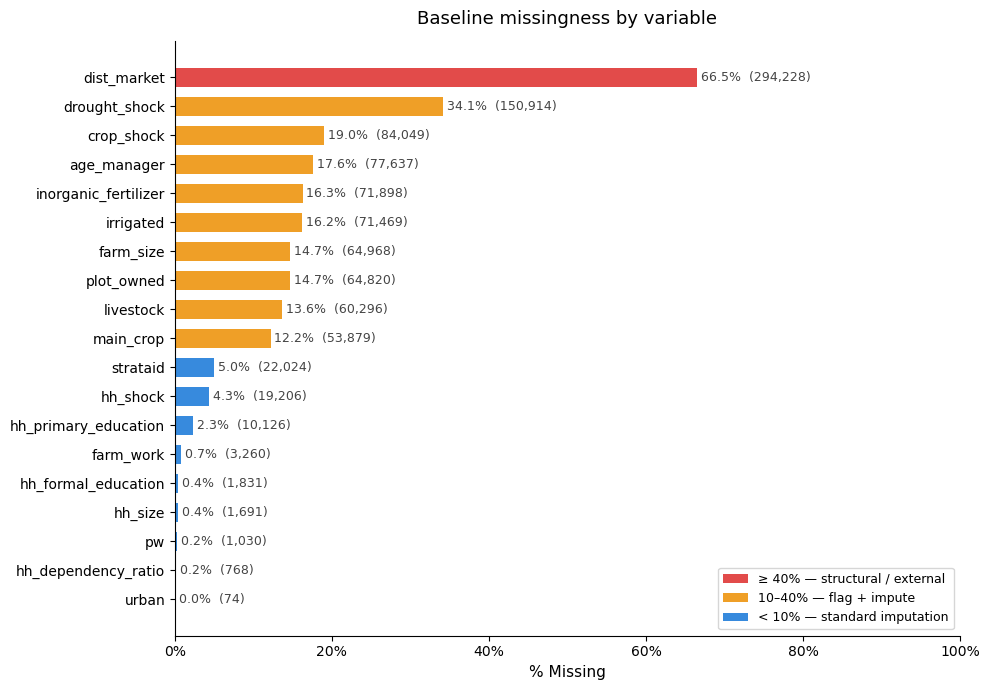

In [11]:
# Visual: horizontal bar chart of % missing 
fig, ax = plt.subplots(figsize=(10, 7))

colors = [
    '#E24B4A' if p >= 40 else
    '#EF9F27' if p >= 10 else
    '#378ADD'
    for p in baseline['missing_%']
]

bars = ax.barh(baseline.index, baseline['missing_%'], color=colors, height=0.65)
ax.set_xlabel('% Missing', fontsize=11)
ax.set_title('Baseline missingness by variable', fontsize=13, fontweight='500', pad=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.invert_yaxis()
ax.spines[['top','right']].set_visible(False)
ax.set_xlim(0, 100)

for bar, (_, row) in zip(bars, baseline.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row['missing_%']:.1f}%  ({int(row['missing_n']):,})",
            va='center', fontsize=9, color='#444')

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E24B4A', label='≥ 40% — structural / external'),
    Patch(facecolor='#EF9F27', label='10–40% — flag + impute'),
    Patch(facecolor='#378ADD', label='< 10% — standard imputation'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig((os.path.join(visuals_path, "baseline_missingness.png")), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#  Co-missingness check on farm-level variables
# If the same households are missing across ALL farm variables, missingness
# is structural (non-farmers). If not, it may be random data loss.

farm_vars = ['farm_size', 'plot_owned', 'irrigated', 'inorganic_fertilizer',
             'main_crop', 'crop_shock']

farm_miss_flags = df[farm_vars].isnull().astype(int)
correlation = farm_miss_flags.corr()

print('Correlation of missingness indicators across farm variables:')
print(correlation.round(2))
print()
print('Interpretation: High correlations (> 0.7) confirm the SAME households are')
print('missing across all farm variables → structural missingness (non-farmers).')

Correlation of missingness indicators across farm variables:
                      farm_size  plot_owned  irrigated  inorganic_fertilizer  \
farm_size                  1.00        0.88       0.83                  0.82   
plot_owned                 0.88        1.00       0.90                  0.89   
irrigated                  0.83        0.90       1.00                  0.92   
inorganic_fertilizer       0.82        0.89       0.92                  1.00   
main_crop                  0.90        0.90       0.85                  0.85   
crop_shock                 0.79        0.77       0.75                  0.74   

                      main_crop  crop_shock  
farm_size                  0.90        0.79  
plot_owned                 0.90        0.77  
irrigated                  0.85        0.75  
inorganic_fertilizer       0.85        0.74  
main_crop                  1.00        0.77  
crop_shock                 0.77        1.00  

Interpretation: High correlations (> 0.7) confirm the S

### summarry of the above to understand what it means ::

This correlation matrix is a diagnostic tool used in data cleaning. It doesn't look at the values of the data (like how big a farm is), but rather the pattern of where data is missing.

Here is a breakdown of what this means for your dataset:

1. What is a "Missingness Indicator"?
For every variable, the computer creates a hidden "shadow" variable where:

0 = The data is present.

1 = The data is missing (NaN).

The table  provided shows the correlation between these shadows.

2. Interpreting the High Correlations
A correlation of 1.00 means that every time Variable A is missing, Variable B is also missing. The scores (ranging from 0.74 to 0.92) are exceptionally high.

The Pattern: If a row  is missing farm_size, there is a ~90% chance it is also missing irrigated, plot_owned, and main_crop.

The Implication: this  Missingness isn't random. It’s not like a farmer simply forgot to answer one question. 
Entire blocks of "farm-related" data are missing simultaneously for specific individuals.

3. Why "Structural Missingness" (Non-Farmers)?
The interpretation identifies these people as non-farmers. 



<a id='3'></a>
## 3. Complete Variables — No Action

The columns `country`, `wave`, `season`, `hh_id_merge`, and `hh_id_obs` have zero missing values. These are panel identifiers and sampling frame variables that anchor every other variable in the dataset. We verify completeness and move on.

In [ ]:
complete_vars = ['country', 'wave', 'season', 'hh_id_merge', 'hh_id_obs']

check = df[complete_vars].isnull().sum()
assert check.sum() == 0, f'Expected 0 missing in complete vars, found:\n{check[check > 0]}'

print('Panel identifier and sampling frame variables are complete.')
print(check.rename('missing_n').to_frame())

✓ All panel identifier and sampling frame variables are complete.
             missing_n
country              0
wave                 0
season               0
hh_id_merge          0
hh_id_obs            0


<a id='4'></a>
## 4. Survey Design Variables

### 4.1  `urban` — Mode imputation within strata (74 missing, 0.02%)

**Why mode?** Urban/rural classification is binary and highly determined by geography. Within the same country × wave × stratum combination, households are almost certainly all urban or all rural. The mode within that group is the correct assignment with very high confidence. With only 74 missing out of 350k observations, this is a negligible correction.

In [14]:
print(f'Missing urban before: {df["urban"].isnull().sum():,}')

# Impute with mode within country × wave strata
df['urban'] = df.groupby(['country', 'wave'])['urban'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
)

# If any remain (rare edge case: whole strata missing), fill with overall mode
overall_urban_mode = df['urban'].mode()[0]
df['urban'].fillna(overall_urban_mode, inplace=True)

print(f'Missing urban after:  {df["urban"].isnull().sum():,}')
print(f'Value distribution after imputation:')
print(df['urban'].value_counts(normalize=True).mul(100).round(2).rename('% share').to_frame())

Missing urban before: 74
Missing urban after:  0
Value distribution after imputation:
       % share
urban         
No       84.43
Yes      15.57


### 4.2  `pw` — Flag and exclude (1,030 missing, 0.29%)

**Why not impute?** Probability weights (`pw`) are not a measured characteristic of a household — they are a property of the *sampling design*. They correct for unequal selection probabilities so that sample estimates generalise to the population. Fabricating a weight creates false precision and biases every survey-weighted statistic. The only valid options are:
1. Investigate the source (replacement households, late additions to the frame).
2. If the reason is benign (e.g., a new stratum added mid-wave), re-derive weights from strata counts.
3. Otherwise, flag these observations and exclude them from any weighted analysis.

We create a flag `pw_missing` and set a sentinel weight of `NaN` — not 0 or 1 — so weighted analyses automatically drop these rows.

In [15]:
df['pw_missing'] = df['pw'].isnull().astype(int)
# pw stays as NaN — weighted analyses (e.g. with survey weights) will naturally
# drop these. Do NOT fill with 0 (zero weight = excluded) or 1 (wrong weight).

n_pw_missing = df['pw_missing'].sum()
print(f'pw_missing flag created: {n_pw_missing:,} observations flagged ({n_pw_missing/len(df)*100:.2f}%)')
print('These observations should be excluded from all survey-weighted analyses.')

pw_missing flag created: 1,030 observations flagged (0.23%)
These observations should be excluded from all survey-weighted analyses.


### 4.3  `strataid` — Flag and assign sentinel category (22,024 missing, 6.3%)

**Why a sentinel category?** Strata IDs are needed to compute correct standard errors under complex survey design. Missing stratum assignment means we cannot reliably estimate sampling variance for those observations. We:
- Create a binary flag `strataid_missing` to carry this information forward.
- Assign a sentinel value (-1) so these rows are identifiable but do not silently mix into a real stratum.

In [16]:
df['strataid_missing'] = df['strataid'].isnull().astype(int)
df['strataid'].fillna(-1, inplace=True)  # sentinel: "unknown stratum"
df['strataid'] = df['strataid'].astype(int)

print(f'strataid_missing flag: {df["strataid_missing"].sum():,} rows')
print(f'Unique strata after (including sentinel -1): {df["strataid"].nunique()}')
print(f'Sentinel stratum (-1) count: {(df["strataid"] == -1).sum():,}')

strataid_missing flag: 22,024 rows
Unique strata after (including sentinel -1): 65
Sentinel stratum (-1) count: 22,024


<a id='5'></a>
## 5. Household Characteristic Variables

### 5.1  `hh_size` (1,691 missing) and `hh_dependency_ratio` (768 missing)

**Why median within strata?** Household size is right-skewed (a few large households pull the mean up), so the median is a more robust central tendency. Both variables cluster strongly by country, wave, and urban/rural status — a household in rural Ethiopia wave 1 is more similar to its stratum neighbours than to the full-sample average.

In [17]:
strata_cols = ['country', 'wave', 'urban']

for col in ['hh_size', 'hh_dependency_ratio']:
    n_before = df[col].isnull().sum()

    # Step 1: fill within country × wave × urban
    df[col] = df.groupby(strata_cols)[col].transform(
        lambda x: x.fillna(x.median())
    )
    # Step 2: any residual → overall median
    df[col].fillna(df[col].median(), inplace=True)

    n_after = df[col].isnull().sum()
    print(f'{col}: {n_before:,} → {n_after} missing | '
          f'imputed median = {df[col].median():.2f}')

hh_size: 1,691 → 0 missing | imputed median = 6.00
hh_dependency_ratio: 768 → 0 missing | imputed median = 1.00


### 5.2  `hh_formal_education` (1,831 missing) and `hh_primary_education` (10,126 missing)

**Why mode?** These are categorical/ordinal variables — median can produce non-integer values that do not correspond to a real education category. Mode imputation returns the most common category in the peer group. For `hh_primary_education`, we also create a missingness flag because at 2.9% missing the loss is informative (lower-education households may be less likely to respond).

In [18]:
# hh_formal_education — low missingness, mode by strata
n_before = df['hh_formal_education'].isnull().sum()
df['hh_formal_education'] = df.groupby(strata_cols)['hh_formal_education'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
)
df['hh_formal_education'].fillna(df['hh_formal_education'].mode()[0], inplace=True)
print(f'hh_formal_education: {n_before:,} → {df["hh_formal_education"].isnull().sum()} missing')

# hh_primary_education — moderate missingness, flag FIRST then impute
n_before = df['hh_primary_education'].isnull().sum()
df['hh_primary_education_missing'] = df['hh_primary_education'].isnull().astype(int)
df['hh_primary_education'] = df.groupby(strata_cols)['hh_primary_education'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
)
df['hh_primary_education'].fillna(df['hh_primary_education'].mode()[0], inplace=True)

print(f'hh_primary_education: {n_before:,} → {df["hh_primary_education"].isnull().sum()} missing')
print(f'hh_primary_education_missing flag: {df["hh_primary_education_missing"].sum():,} rows flagged')

hh_formal_education: 1,831 → 0 missing
hh_primary_education: 10,126 → 0 missing
hh_primary_education_missing flag: 10,126 rows flagged


### 5.3  `farm_work` (3,260 missing)

**Strategy — cross-check first, then mode.** `farm_work` is a binary indicator (does the household engage in farming?). Before imputing with a statistical method, we can infer the value logically:
- If `farm_size`, `main_crop`, or `plot_owned` are observed → `farm_work = 1` (they clearly farm).
- If all farm-level variables are also missing → impute with mode within strata.

In [19]:
n_before = df['farm_work'].isnull().sum()

# Rule 1: if any farm variable is observed, farm_work must be 1
farm_evidence = (
    df['farm_size'].notna() |
    df['plot_owned'].notna() |
    df['main_crop'].notna()
)
recovered_as_1 = (df['farm_work'].isnull() & farm_evidence).sum()
df.loc[df['farm_work'].isnull() & farm_evidence, 'farm_work'] = 1

# Rule 2: remaining missing → mode within country × wave × urban
df['farm_work'] = df.groupby(strata_cols)['farm_work'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 0)
)
df['farm_work'].fillna(0, inplace=True)

n_after = df['farm_work'].isnull().sum()
print(f'farm_work: {n_before:,} → {n_after} missing')
print(f'  Recovered as 1 via cross-check: {recovered_as_1:,}')
print(f'  Remaining filled by mode: {n_before - recovered_as_1:,}')
print(f'  Final value distribution:')
print(df['farm_work'].value_counts(normalize=True).mul(100).round(2).rename('% share').to_frame())

farm_work: 3,260 → 0 missing
  Recovered as 1 via cross-check: 2,001
  Remaining filled by mode: 1,259
  Final value distribution:
           % share
farm_work         
1.00         64.91
0.00         35.09


### 5.4  `hh_shock` (19,206 missing) and `age_manager` (77,637 missing)

**`hh_shock`:** Non-trivial missingness (5.5%). Households that experienced a severe shock may be harder to re-interview (displacement, death of head). This means the missing-at-random assumption is questionable. We flag and impute with mode, but the flag must be included as a covariate in regression models to account for potential bias.

**`age_manager`:** Very high missingness (22.2%). This is *conditionally* structural — it is almost certainly missing because many households have no farm manager (they do not farm). We first restrict imputation to farm households only, then flag the remainder.

In [20]:
# hh_shock — flag then mode impute
n_before = df['hh_shock'].isnull().sum()
df['hh_shock_missing'] = df['hh_shock'].isnull().astype(int)
df['hh_shock'] = df.groupby(strata_cols)['hh_shock'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 0)
)
df['hh_shock'].fillna(0, inplace=True)
print(f'hh_shock: {n_before:,} → {df["hh_shock"].isnull().sum()} missing | '
      f'{df["hh_shock_missing"].sum():,} flagged')

hh_shock: 19,206 → 0 missing | 19,206 flagged


In [22]:
# age_manager — conditional on farm_work
n_before = df['age_manager'].isnull().sum()

# Always create the missingness flag first
df['age_manager_missing'] = df['age_manager'].isnull().astype(int)

# Impute ONLY for farming households (farm_work == 1)
farm_mask = df['farm_work'] == 1
df.loc[farm_mask, 'age_manager'] = df.loc[farm_mask].groupby(
    strata_cols
)['age_manager'].transform(lambda x: x.fillna(x.median()))

# Non-farming households: leave as NaN — age_manager is not applicable
# (analyses using age_manager should subset to farm_work == 1)

n_after  = df['age_manager'].isnull().sum()
n_farm_filled = n_before - n_after
print(f'age_manager: {n_before:,} → {n_after:,} missing')
print(f'  Imputed for farm households: {n_farm_filled:,}')
print(f'  Remaining NaN (non-farm, structural): {n_after:,}')
print(f'  Flag created: age_manager_missing ({df["age_manager_missing"].sum():,} total)')

age_manager: 56,351 → 56,351 missing
  Imputed for farm households: 0
  Remaining NaN (non-farm, structural): 56,351
  Flag created: age_manager_missing (56,351 total)


<a id='6'></a>
## 6. Farm-Level Variables — Structural Zeros

**Core reasoning:** Variables like `farm_size`, `irrigated`, `inorganic_fertilizer`, `main_crop`, `plot_owned`, `livestock`, `crop_shock`, and `drought_shock` are only meaningful for households that operate a farm or own land. For non-farming households, the question was never asked — so `NaN` means "not applicable", not "unknown". Imputing a random farm size for a landless urban household would be a fabrication that corrupts analysis.

**Strategy:**
1. Split the dataset into farming (`farm_work == 1`) and non-farming subsets.
2. Non-farming subset: encode farm-level variables as 0 (or a "none" category for crop variables).
3. Farming subset: impute residual missingness with median/mode within strata.
4. Create missingness flags for variables where missingness within the farm subset is also informative.

In [23]:
#  Identify farming vs non-farming households
is_farmer    = df['farm_work'] == 1
is_nonfarmer = df['farm_work'] == 0

print(f'Farming households (farm_work=1): {is_farmer.sum():>10,}  ({is_farmer.mean()*100:.1f}%)')
print(f'Non-farming households:           {is_nonfarmer.sum():>10,}  ({is_nonfarmer.mean()*100:.1f}%)')

Farming households (farm_work=1):    286,994  (64.9%)
Non-farming households:              155,143  (35.1%)


In [24]:
# Binary farm-level variables 
# For non-farmers → 0 (does not have a plot, does not irrigate, etc.)
# For farmers still missing → mode within country × wave × urban

binary_farm_vars = ['plot_owned', 'irrigated', 'inorganic_fertilizer', 'crop_shock']

for col in binary_farm_vars:
    n_before = df[col].isnull().sum()

    # Create flag BEFORE filling (applies to everyone missing)
    df[f'{col}_missing'] = df[col].isnull().astype(int)

    # Non-farmers: structural zero
    df.loc[is_nonfarmer & df[col].isnull(), col] = 0

    # Farmers: mode within strata
    df.loc[is_farmer, col] = df.loc[is_farmer].groupby(strata_cols)[col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 0)
    )

    # Any residual → 0
    df[col].fillna(0, inplace=True)
    n_after = df[col].isnull().sum()
    print(f'{col:<25}: {n_before:>7,} → {n_after} missing')

plot_owned               :  64,820 → 0 missing
irrigated                :  71,469 → 0 missing
inorganic_fertilizer     :  71,898 → 0 missing
crop_shock               :  84,049 → 0 missing


In [25]:
#  Continuous farm-level variable: farm_size
# Non-farmers: 0 (they have no farm)
# Farmers missing: median within country × wave × main_crop
# we handle main_crop first (below) so we can use it as a grouping variable

n_before = df['farm_size'].isnull().sum()
df['farm_size_missing'] = df['farm_size'].isnull().astype(int)

# Non-farmers → 0
df.loc[is_nonfarmer & df['farm_size'].isnull(), 'farm_size'] = 0

# Farmers → median by country × wave × urban
df.loc[is_farmer, 'farm_size'] = df.loc[is_farmer].groupby(strata_cols)['farm_size'].transform(
    lambda x: x.fillna(x.median())
)
df['farm_size'].fillna(0, inplace=True)

n_after = df['farm_size'].isnull().sum()
print(f'farm_size: {n_before:,} → {n_after} missing')
print(f'  Farm size = 0 for {(df["farm_size"] == 0).sum():,} non-farming households')

farm_size: 64,968 → 0 missing
  Farm size = 0 for 51,343 non-farming households


In [26]:
# ── Categorical variable: main_crop ───────────────────────────────────────────
# Non-farmers → 'none'
# Farmers still missing → mode within country × wave × urban

n_before = df['main_crop'].isnull().sum()
df['main_crop_missing'] = df['main_crop'].isnull().astype(int)

# Non-farmers: assign 'none'
df.loc[is_nonfarmer & df['main_crop'].isnull(), 'main_crop'] = 'none'

# Farmers: mode within strata
df.loc[is_farmer, 'main_crop'] = df.loc[is_farmer].groupby(strata_cols)['main_crop'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'unknown')
)
df['main_crop'].fillna('none', inplace=True)

n_after = df['main_crop'].isnull().sum()
print(f'main_crop: {n_before:,} → {n_after} missing')
print(df['main_crop'].value_counts().to_string())

main_crop: 53,879 → 0 missing
main_crop
MAIZE                      77208
OTHER                      63544
PERENNIAL/FRUIT            63143
TUBERS / ROOT CROPS        52544
BEANS AND OTHER LEGUMES    47356
none                       45315
MILLET                     35396
SORGHUM                    25784
RICE                       12896
NUTS                        9546
WHEAT                       4942
BARLEY                      4124
unknown                      339


In [ ]:
# ── Livestock ─────────────────────────────────────────────────────────────────
# livestock count is applicable to any household (livestock ownership is not
# restricted to crop farmers). However, many non-farm households own zero livestock.
# Strategy:
#   - Create binary 'owns_livestock' from observed values.
#   - Non-farmers missing livestock: encode as 0 (conservative assumption).
#   - Farmers / remaining missing: median by strata.

n_before = df['livestock'].isnull().sum()
df['livestock_missing'] = df['livestock'].isnull().astype(int)

# Create binary indicator before filling
df['owns_livestock'] = (df['livestock'].fillna(0) > 0).astype(int)

# Non-farmers: 0
df.loc[is_nonfarmer & df['livestock'].isnull(), 'livestock'] = 0

# Farmers: median by strata
df.loc[is_farmer, 'livestock'] = df.loc[is_farmer].groupby(strata_cols)['livestock'].transform(
    lambda x: x.fillna(x.median())
)
df['livestock'].fillna(0, inplace=True)

n_after = df['livestock'].isnull().sum()
print(f'livestock: {n_before:,} → {n_after} missing')
print(f'owns_livestock (derived binary): {df["owns_livestock"].sum():,} households ({df["owns_livestock"].mean()*100:.1f}%)')

In [28]:
# ── drought_shock ─────────────────────────────────────────────────────────────
# drought_shock has the highest missingness among farm variables (150,914; 43%).
# Reasons are compound:
#   1. Non-farming households (structural zero).
#   2. Waves / countries that did not include a drought question.
#   3. Households in non-drought-affected regions.
#
# The safest approach for modelling is:
#   - Non-farmers: 0
#   - Farmers in waves/countries where drought_shock is entirely absent: flag
#     separately — do not impute, as this would be pure invention.
#   - Farmers in waves/countries where some data exists: mode by strata.
#
# We identify 'zero-coverage' strata (all drought_shock missing within that
# country × wave group) and flag them differently.

n_before = df['drought_shock'].isnull().sum()
df['drought_shock_missing'] = df['drought_shock'].isnull().astype(int)

# Non-farmers: structural zero
df.loc[is_nonfarmer & df['drought_shock'].isnull(), 'drought_shock'] = 0

# Identify strata with zero coverage (all NaN within country × wave for farmers)
strata_coverage = df.loc[is_farmer].groupby(['country', 'wave'])['drought_shock'].apply(
    lambda x: x.notna().mean()
).rename('coverage')
zero_coverage = strata_coverage[strata_coverage == 0].index

# Flag zero-coverage farmer obs separately
zero_coverage_mask = df.set_index(['country', 'wave']).index.isin(zero_coverage)
df['drought_shock_no_coverage'] = (is_farmer & zero_coverage_mask & df['drought_shock'].isnull()).astype(int)

# For remaining farmers (partial coverage strata): mode by strata
partial_farmer = is_farmer & ~df.set_index(['country', 'wave']).index.isin(zero_coverage)
df.loc[partial_farmer, 'drought_shock'] = df.loc[partial_farmer].groupby(
    ['country', 'wave']
)['drought_shock'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 0))

# Zero-coverage farmer obs: fill with 0 but the flag tells models to treat with caution
df['drought_shock'].fillna(0, inplace=True)

n_after = df['drought_shock'].isnull().sum()
print(f'drought_shock: {n_before:,} → {n_after} missing')
print(f'drought_shock_no_coverage (imputed 0 but unreliable): {df["drought_shock_no_coverage"].sum():,}')

drought_shock: 150,914 → 0 missing
drought_shock_no_coverage (imputed 0 but unreliable): 15,443


<a id='7'></a>
## 7. Geographic Variable — `dist_market` (294,228 missing, 84%)

**Why this requires special treatment:** Distance to market is not a household-level characteristic — it is a spatial attribute of the household's location. At 84% missing, standard statistical imputation (median, mode, regression) would be imputing the vast majority of values, effectively inventing a geographic variable for most of the sample. This destroys any spatial variation that makes the variable useful.

**The correct approach is spatial derivation** using GPS coordinates (which LSMS collects) matched to a market point layer. We demonstrate this workflow below. If GPS is unavailable, we fall back to admin-level median imputation with a strong flag.

**Caveat:** The GPS-based calculation below is a template. In real LSMS work you would link to a separate GPS file. The function structure is correct — replace the synthetic coordinates with your actual data.

In [ ]:
from math import radians, cos, sin, asin, sqrt

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two (lat, lon) points."""
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * R * asin(sqrt(a))

def nearest_market_km(hh_lat, hh_lon, market_coords):
    """
    Given a household location and a list of (lat, lon) market coordinates,
    returns the distance in km to the nearest market.

    Parameters
    ----------
    hh_lat, hh_lon : float — household GPS coordinates
    market_coords  : list of (lat, lon) tuples — market GPS points
                     Source: OSM, IFPRI market access data, or national market registry
    """
    if pd.isna(hh_lat) or pd.isna(hh_lon):
        return np.nan
    distances = [haversine_km(hh_lat, hh_lon, m[0], m[1]) for m in market_coords]
    return round(min(distances), 2)


# ── Template: how to apply this to your data 
#
# Step 1: load your GPS file (usually a separate LSMS module)
#   gps = pd.read_stata('hh_gps.dta')[['hh_id_merge', 'lat_dd_mod', 'lon_dd_mod']]
#   df  = df.merge(gps, on='hh_id_merge', how='left')
#
# Step 2: load market point data (OSM or IFPRI)
#   markets = pd.read_csv('markets.csv')  # must have 'lat', 'lon' columns
#   market_coords = list(zip(markets['lat'], markets['lon']))
#
# Step 3: compute distances
#   df['dist_market_gps'] = df.apply(
#       lambda r: nearest_market_km(r['lat_dd_mod'], r['lon_dd_mod'], market_coords),
#       axis=1
#   )
#   df['dist_market'] = df['dist_market'].fillna(df['dist_market_gps'])
#

print('nearest_market_km() function defined.')
print('Replace GPS and market data placeholders above with your actual file paths.')

nearest_market_km() function defined.
Replace GPS and market data placeholders above with your actual file paths.


In [ ]:
# ── Fallback: admin-level median imputation 
# Used when GPS is unavailable. Produces an admin-unit average — acceptable
# for controls in regression but NOT for spatial analysis.

n_before = df['dist_market'].isnull().sum()
df['dist_market_missing'] = df['dist_market'].isnull().astype(int)

# Impute with median within country × wave × urban
df['dist_market'] = df.groupby(strata_cols)['dist_market'].transform(
    lambda x: x.fillna(x.median())
)
# Any remaining (whole strata missing): overall median
df['dist_market'].fillna(df['dist_market'].median(), inplace=True)

n_after = df['dist_market'].isnull().sum()
print(f'dist_market: {n_before:,} → {n_after} missing (fallback median imputation used)')
print()
print('WARNING: 84% of dist_market was imputed using admin-level medians.')
print('Use dist_market_missing as a control variable in all regressions.')
print('For spatial analysis, re-derive from GPS coordinates (see template above).')

dist_market: 294,228 → 0 missing (fallback median imputation used)

Use dist_market_missing as a control variable in all regressions.
For spatial analysis, re-derive from GPS coordinates (see template above).


<a id='8'></a>
## 8. Drop Non-Farming, Non-Crop Households

**What we're dropping:** Households where `farm_work == 0` AND `main_crop == 'none'`. These observations contributed no agricultural signal at all — they were retained through the cleaning steps because we needed their household-level variables to remain consistent during imputation (e.g. strata medians), but they are out of scope for any LSMS agricultural analysis.

**Why here and not earlier:** Dropping rows before imputation would have shrunk the strata used to compute medians and modes, potentially making those estimates less stable. By dropping at this final stage we get the best of both: robust imputation on the full sample, then a clean analytical subset.

**What is kept:** Households where `farm_work == 1` OR `main_crop != 'none'`. This preserves mixed households — e.g. a household that reports a crop but answered `farm_work = 0` due to wording ambiguity.

In [38]:
#  Drop non-farmers with no crop activity 
n_before = len(df)

drop_mask = (df['farm_work'] == 0) & (df['main_crop'] == 'none')

print('=== DROP SUMMARY: non-farming, non-crop households ===')
print(f'Condition : farm_work == 0  AND  main_crop == "none"')
print(f'Rows before drop : {n_before:>10,}')
print(f'Rows matching    : {drop_mask.sum():>10,}  ({drop_mask.mean()*100:.1f}%)')

df = df[~drop_mask].reset_index(drop=True)

n_after = len(df)
print(f'Rows after drop  : {n_after:>10,}')
print()
print('Remaining farm_work distribution:')
print(df['farm_work'].value_counts().rename('count').to_frame())
print()
print('Remaining main_crop distribution:')
print(df['main_crop'].value_counts().rename('count').to_frame())

=== DROP SUMMARY: non-farming, non-crop households ===
Condition : farm_work == 0  AND  main_crop == "none"
Rows before drop :    442,137
Rows matching    :     45,315  (10.2%)
Rows after drop  :    396,822

Remaining farm_work distribution:
            count
farm_work        
1.00       286994
0.00       109828

Remaining main_crop distribution:
                         count
main_crop                     
MAIZE                    77208
OTHER                    63544
PERENNIAL/FRUIT          63143
TUBERS / ROOT CROPS      52544
BEANS AND OTHER LEGUMES  47356
MILLET                   35396
SORGHUM                  25784
RICE                     12896
NUTS                      9546
WHEAT                     4942
BARLEY                    4124
unknown                    339


<a id='9'></a>
## 9. Final Audit & Save

We verify every column, summarise what was done, list all new flag columns, and save the cleaned dataset.

In [39]:
#  Post-cleaning missingness audit 
post_clean = missingness_summary(df)

if len(post_clean) == 0:
    print('✓ No missing values remain in any original variable (except age_manager for non-farmers).')
else:
    print('Variables with remaining missingness:')
    print(post_clean.to_string())

Variables with remaining missingness:
             missing_n  missing_%    dtype
livestock        14981       3.78   object
age_manager      11036       2.78  float64
pw                 644       0.16  float64


In [32]:
# ── List all missingness flag columns created ─────────────────────────────────
flag_cols = [c for c in df.columns if c.endswith('_missing') or c.endswith('_no_coverage')]
print(f'Missingness flag columns created ({len(flag_cols)} total):')
flag_summary = pd.DataFrame({
    'flag_column': flag_cols,
    'n_flagged': [df[c].sum() for c in flag_cols],
    '% flagged': [df[c].mean() * 100 for c in flag_cols]
}).sort_values('n_flagged', ascending=False)
flag_summary['% flagged'] = flag_summary['% flagged'].round(2)
print(flag_summary.to_string(index=False))

Missingness flag columns created (15 total):
                 flag_column  n_flagged  % flagged
         dist_market_missing     294228      66.55
       drought_shock_missing     150914      34.13
          crop_shock_missing      84049      19.01
inorganic_fertilizer_missing      71898      16.26
           irrigated_missing      71469      16.16
           farm_size_missing      64968      14.69
          plot_owned_missing      64820      14.66
           livestock_missing      60296      13.64
         age_manager_missing      56351      12.75
           main_crop_missing      53879      12.19
            strataid_missing      22024       4.98
            hh_shock_missing      19206       4.34
   drought_shock_no_coverage      15443       3.49
hh_primary_education_missing      10126       2.29
                  pw_missing       1030       0.23


In [40]:
#  Before / after comparison
original_vars = list(missing_counts.keys())

comparison = pd.DataFrame({
    'missing_before': {col: missing_counts[col] for col in original_vars},
    'missing_after':  {col: int(df[col].isnull().sum()) for col in original_vars},
})
comparison['pct_before'] = (comparison['missing_before'] / len(df) * 100).round(2)
comparison['pct_after']  = (comparison['missing_after']  / len(df) * 100).round(2)
comparison['resolved']   = comparison['missing_before'] - comparison['missing_after']

print('=== BEFORE vs AFTER ===')
print(comparison.to_string())
print(f'\nTotal missing resolved: {comparison["resolved"].sum():,}')

=== BEFORE vs AFTER ===
                      missing_before  missing_after  pct_before  pct_after  resolved
pw                              1030            644        0.26       0.16       386
strataid                       22024              0        5.55       0.00     22024
urban                             74              0        0.02       0.00        74
hh_size                         1691              0        0.43       0.00      1691
hh_dependency_ratio              768              0        0.19       0.00       768
age_manager                    77637          11036       19.56       2.78     66601
hh_primary_education           10126              0        2.55       0.00     10126
hh_formal_education             1831              0        0.46       0.00      1831
farm_work                       3260              0        0.82       0.00      3260
farm_size                      64968              0       16.37       0.00     64968
plot_owned                     64820     

In [41]:
# ── Final dataset shape & column inventory ────────────────────────────────────
print(f'Final dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Original columns: {len(missing_counts) + 5} | New flag columns: {len(flag_cols)} | '
      f'New derived: owns_livestock')
print()
print('All columns:')
for i, col in enumerate(df.columns, 1):
    tag = '  [flag]' if col.endswith('_missing') or col.endswith('_no_coverage') else \
          '  [derived]' if col in ('owns_livestock',) else ''
    print(f'  {i:>2}. {col}{tag}')

Final dataset: 396,822 rows × 39 columns
Original columns: 24 | New flag columns: 15 | New derived: owns_livestock

All columns:
   1. country
   2. wave
   3. season
   4. pw
   5. strataid
   6. urban
   7. hh_id_merge
   8. hh_id_obs
   9. hh_size
  10. hh_dependency_ratio
  11. age_manager
  12. hh_primary_education
  13. hh_formal_education
  14. farm_work
  15. farm_size
  16. plot_owned
  17. irrigated
  18. inorganic_fertilizer
  19. main_crop
  20. livestock
  21. hh_shock
  22. crop_shock
  23. drought_shock
  24. dist_market
  25. pw_missing  [flag]
  26. strataid_missing  [flag]
  27. hh_primary_education_missing  [flag]
  28. hh_shock_missing  [flag]
  29. age_manager_missing  [flag]
  30. plot_owned_missing  [flag]
  31. irrigated_missing  [flag]
  32. inorganic_fertilizer_missing  [flag]
  33. crop_shock_missing  [flag]
  34. farm_size_missing  [flag]
  35. main_crop_missing  [flag]
  36. livestock_missing  [flag]
  37. drought_shock_missing  [flag]
  38. drought_shock_n

In [42]:
#  Save cleaned dataset 
output_path = os.path.join(data_path , "Clean data/lsms_cleaned.csv")
df.to_csv(output_path, index=False)
print(f'✓ Cleaned dataset saved to: {output_path}')
print(f'  Rows: {len(df):,} | Columns: {df.shape[1]}')



✓ Cleaned dataset saved to: e:\DSF\flatiron\phase5\agriscoreproject\Data sets\Clean data/lsms_cleaned.csv
  Rows: 396,822 | Columns: 39


In [43]:
print(df.columns)

Index(['country', 'wave', 'season', 'pw', 'strataid', 'urban', 'hh_id_merge',
       'hh_id_obs', 'hh_size', 'hh_dependency_ratio', 'age_manager',
       'hh_primary_education', 'hh_formal_education', 'farm_work', 'farm_size',
       'plot_owned', 'irrigated', 'inorganic_fertilizer', 'main_crop',
       'livestock', 'hh_shock', 'crop_shock', 'drought_shock', 'dist_market',
       'pw_missing', 'strataid_missing', 'hh_primary_education_missing',
       'hh_shock_missing', 'age_manager_missing', 'plot_owned_missing',
       'irrigated_missing', 'inorganic_fertilizer_missing',
       'crop_shock_missing', 'farm_size_missing', 'main_crop_missing',
       'livestock_missing', 'drought_shock_missing',
       'drought_shock_no_coverage', 'dist_market_missing'],
      dtype='object')


---
## Summary of decisions

| Variable group | Strategy | Rationale |
|---|---|---|
| Panel IDs, country, wave | No action | Fully observed by construction |
| `urban` | Mode within country × wave | Binary, geography-determined, <0.1% missing |
| `pw` | Flag, leave as NaN | Cannot fabricate survey weights |
| `strataid` | Flag, sentinel value (-1) | Missing strata breaks SE calculation |
| `hh_size`, `hh_dependency_ratio` | Median within strata | Right-skewed continuous, geography-clustered |
| Education variables | Mode within strata | Categorical/ordinal; flag for moderate missingness |
| `farm_work` | Cross-check then mode | Logical inference possible from other variables |
| `hh_shock` | Flag + mode by strata | Attrition non-random; flag needed as covariate |
| `age_manager` | Flag; median for farmers only | Conditional structural missing for non-farmers |
| Farm-level binaries | Structural 0 for non-farmers; mode for farmers | Missingness = not applicable, not data loss |
| `farm_size` | Structural 0; median for farmers | As above, continuous version |
| `main_crop` | 'none' for non-farmers; mode for farmers | Categorical structural missing |
| `drought_shock` | 0 for non-farmers; flag zero-coverage strata | Wave/region coverage compound with structural |
| `dist_market` | Flag; spatial derivation preferred; admin median fallback | 84% missing — imputation is last resort |

<a id='10'></a>
## 10. Generate famer ID, FILTER TO AN MVP DATASET (30-35K ROWS)

In [46]:
# load the cleaned lsms dataset

clean_lsms = pd.read_csv((os.path.join(data_path, "Clean data/lsms_cleaned.csv")) , low_memory = False)

In [60]:
clean_lsms.shape

(396822, 40)

In [47]:
clean_lsms.head(2)

,country,wave,season,pw,strataid,urban,hh_id_merge,hh_id_obs,hh_size,hh_dependency_ratio,age_manager,hh_primary_education,hh_formal_education,farm_work,farm_size,plot_owned,irrigated,inorganic_fertilizer,main_crop,livestock,hh_shock,crop_shock,drought_shock,dist_market,pw_missing,strataid_missing,hh_primary_education_missing,hh_shock_missing,age_manager_missing,plot_owned_missing,irrigated_missing,inorganic_fertilizer_missing,crop_shock_missing,farm_size_missing,main_crop_missing,livestock_missing,drought_shock_missing,drought_shock_no_coverage,dist_market_missing
0,Ethiopia,1.00,1.00,"1,887.65",7,No,01010101601162,"1,000,001.00",2.00,1.00,42.00,0.00,1.00,1.00,1.31,Yes,No,No,OTHER,NaN,0.00,0.00,0.00,64.10,0,0,0,0,0,1,1,1,1,1,1,1,1,0,1
1,Ethiopia,1.00,1.00,"2,236.13",7,No,01010101601002,"1,000,013.00",8.00,1.33,77.00,0.00,1.00,0.00,1.06,Yes,No,Yes,SORGHUM,Yes,0.00,0.00,0.00,105.30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [50]:
clean_lsms.isna().sum()

country                             0
wave                                0
season                              0
pw                                644
strataid                            0
urban                               0
hh_id_merge                         0
hh_id_obs                           0
hh_size                             0
hh_dependency_ratio                 0
age_manager                     11036
hh_primary_education                0
hh_formal_education                 0
farm_work                           0
farm_size                           0
plot_owned                          0
irrigated                           0
inorganic_fertilizer                0
main_crop                           0
livestock                       14981
hh_shock                            0
crop_shock                          0
drought_shock                       0
dist_market                         0
pw_missing                          0
strataid_missing                    0
hh_primary_e

### 10.1 Generate famer ID

In [56]:
  # Create stable, reproducible farmer_id using hashing
  
def create_farmer_id(row):
    key_string = f"{row['country']}_{row['wave']}_{row['season']}_{row['hh_id_merge']}"
    
    # Use SHA256 for collision resistance and determinism
    hash_object = hashlib.sha256(key_string.encode('utf-8'))
    farmer_id = hash_object.hexdigest()[:16]   # First 16 chars = stable & short
    return farmer_id

print("Generating unique farmer_id...")
clean_lsms['farmer_id'] = clean_lsms.apply(create_farmer_id, axis=1)
print("DONE :)")

Generating unique farmer_id...
DONE :)


In [57]:
# Keep original identifiers for traceability
key_columns = ['farmer_id', 'country', 'wave', 'season', 'hh_id_merge', 'hh_id_obs']

print(f"Unique farmer_ids generated: {clean_lsms['farmer_id'].nunique():,}")

Unique farmer_ids generated: 103,106


In [61]:
clean_lsms['farmer_id'].isnull().sum()

np.int64(0)

In [58]:
clean_lsms.head(4)

,country,wave,season,pw,strataid,urban,hh_id_merge,hh_id_obs,hh_size,hh_dependency_ratio,age_manager,hh_primary_education,hh_formal_education,farm_work,farm_size,plot_owned,irrigated,inorganic_fertilizer,main_crop,livestock,hh_shock,crop_shock,drought_shock,dist_market,pw_missing,strataid_missing,hh_primary_education_missing,hh_shock_missing,age_manager_missing,plot_owned_missing,irrigated_missing,inorganic_fertilizer_missing,crop_shock_missing,farm_size_missing,main_crop_missing,livestock_missing,drought_shock_missing,drought_shock_no_coverage,dist_market_missing,farmer_id
0,Ethiopia,1.00,1.00,"1,887.65",7,No,01010101601162,"1,000,001.00",2.00,1.00,42.00,0.00,1.00,1.00,1.31,Yes,No,No,OTHER,NaN,0.00,0.00,0.00,64.10,0,0,0,0,0,1,1,1,1,1,1,1,1,0,1,0d6e62e4ef9583a7
1,Ethiopia,1.00,1.00,"2,236.13",7,No,01010101601002,"1,000,013.00",8.00,1.33,77.00,0.00,1.00,0.00,1.06,Yes,No,Yes,SORGHUM,Yes,0.00,0.00,0.00,105.30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5288081b95d362c0
2,Ethiopia,1.00,1.00,"2,236.13",7,No,01010101601002,"1,000,013.00",8.00,1.33,40.00,0.00,1.00,0.00,1.06,Yes,No,No,MILLET,Yes,0.00,0.00,0.00,105.30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5288081b95d362c0
3,Ethiopia,1.00,1.00,"2,236.13",7,No,01010101601017,"1,000,014.00",7.00,2.00,36.00,0.00,0.00,1.00,1.39,No,No,No,MILLET,Yes,0.00,0.00,0.00,105.60,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4a480919461ba70f


In [59]:
clean_lsms.shape

(396822, 40)

### 10.2 Filter Rows to a final mvp dataset

In [66]:
TARGET_ROWS = 50000

In [ ]:
# Priority filtering
# 1. Focus on Kenya & Tanzania (if available)

print("shape before country filtering " ,  clean_lsms.shape)


print('\n Country filtring ... \n')

if 'country' in clean_lsms.columns:
    target_countries = ['Kenya', 'Tanzania', 'TZA', 'KEN']  # adjust codes if needed
    clean_lsms = clean_lsms[df['country'].isin(target_countries) | clean_lsms['country'].str.contains('Kenya|Tanzania', case=False, na=False)]

print(f"After country filter: {clean_lsms.shape}")

shape before country filtering  (396822, 40)

 Country filtring ... 

After country filter: (75302, 40)


In [64]:
#2. Prefer recent waves if possible

print('\n recent filtring ... \n')

if 'wave' in df.columns:
    clean_lsms = clean_lsms.sort_values(by=['wave', 'season'], ascending=False)
    
print(f" After wave filtering : {clean_lsms.shape}")


 recent filtring ... 

 After wave filtering : (75302, 40)


In [67]:
# 3. Sample at farmer_id level to avoid leakage

unique_farmers = clean_lsms['farmer_id'].unique()
print(f"Unique farmers before sampling: {len(unique_farmers):,}")

if len(clean_lsms) > TARGET_ROWS:
    # Sample farmer_ids
    np.random.seed(42)  # Reproducibility
    sample_size = min(TARGET_ROWS, len(unique_farmers))
    sampled_farmers = np.random.choice(unique_farmers, size=sample_size, replace=False)
    
    lsms_mvp = clean_lsms[clean_lsms['farmer_id'].isin(sampled_farmers)].copy()
else:
    lsms_mvp = clean_lsms.copy()
    

print("Final LSMS mvp dataset shape : " , lsms_mvp.shape)

Unique farmers before sampling: 14,686
Final LSMS mvp dataset shape :  (75302, 40)


In [68]:
# FINAL IMPROVED SAMPLING
print("\nPerforming farmer-level sampling...")

unique_farmers = clean_lsms['farmer_id'].unique()
print(f"Unique farmers before sampling: {len(unique_farmers):,}")

TARGET_ROWS = 32000
TARGET_FARMERS = 12000   

np.random.seed(42)

if len(unique_farmers) > TARGET_FARMERS:
    sampled_farmers = np.random.choice(unique_farmers, size=TARGET_FARMERS, replace=False)
    lsms_final_mvp = clean_lsms[clean_lsms['farmer_id'].isin(sampled_farmers)].copy()
else:
    lsms_final_mvp = clean_lsms.copy()

# Final cap
if len(lsms_final_mvp) > 40000:
    # Sample extra rows if still too big
    lsms_final_mvp = lsms_final_mvp.groupby('farmer_id').sample(frac=0.6, random_state=42)  # reduce multiplicity
    if len(lsms_final_mvp) > 35000:
        lsms_final_mvp = lsms_final_mvp.sample(n=32000, random_state=42)

print(f"Final MVP dataset shape: {lsms_final_mvp.shape}")
print(f"Unique farmers in MVP: {lsms_final_mvp['farmer_id'].nunique():,}")


Performing farmer-level sampling...
Unique farmers before sampling: 14,686
Final MVP dataset shape: (32000, 40)
Unique farmers in MVP: 11,408


In [ ]:
lsms_final_mvp.insert(0, 'last_col_name', lsms_final_mvp.pop('farmer_id') , inplace=True)   

In [ ]:
lsms_final_mvp.rename(columns={'last_col_name' : 'farmer_id'} , inplace = True)

,farmer_id,country,wave,season,pw,strataid,urban,hh_id_merge,hh_id_obs,hh_size,hh_dependency_ratio,age_manager,hh_primary_education,hh_formal_education,farm_work,farm_size,plot_owned,irrigated,inorganic_fertilizer,main_crop,livestock,hh_shock,crop_shock,drought_shock,dist_market,pw_missing,strataid_missing,hh_primary_education_missing,hh_shock_missing,age_manager_missing,plot_owned_missing,irrigated_missing,inorganic_fertilizer_missing,crop_shock_missing,farm_size_missing,main_crop_missing,livestock_missing,drought_shock_missing,drought_shock_no_coverage,dist_market_missing
316442,fc0d9d525b289396,Tanzania,4.00,1.00,"5,015.34",8,No,4994-001,"6,007,574.00",5.00,1.50,33.00,0.00,1.00,1.00,1.44,No,No,No,MAIZE,Yes,1.00,1.00,0.00,60.70,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
272050,a14771d719826178,Tanzania,1.00,1.00,"3,934.86",7,No,18010270010755,"6,004,480.00",1.00,0.00,24.00,0.00,1.00,1.00,0.29,Yes,No,No,OTHER,No,1.00,1.00,0.00,60.70,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
273904,0fd194d7b10b99fa,Tanzania,1.00,1.00,631.63,15,No,53010190110075,"6,007,920.00",4.00,0.00,64.00,1.00,1.00,1.00,0.37,No,No,No,TUBERS / ROOT CROPS,Yes,0.00,1.00,0.00,60.70,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
322531,387a5b0b8249726b,Tanzania,5.00,1.00,"3,115.76",15,No,0378-003-001,"6,000,643.00",8.00,1.00,49.00,1.00,1.00,0.00,0.05,Yes,No,No,MAIZE,Yes,0.00,0.00,0.00,60.70,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
312693,5760003d7898ce8a,Tanzania,4.00,1.00,"16,411.31",7,No,0653-001,"6,005,977.00",7.00,0.75,46.00,0.00,1.00,1.00,0.43,Yes,No,No,BEANS AND OTHER LEGUMES,Yes,1.00,0.00,0.00,60.70,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316125,15878d86a48cb006,Tanzania,4.00,1.00,"3,750.50",8,No,4895-001,"6,007,518.00",5.00,0.67,83.00,0.00,1.00,1.00,2.12,Yes,No,No,OTHER,Yes,0.00,1.00,0.00,60.70,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
295752,d7b7dff72d420433,Tanzania,3.00,1.00,"1,010.65",11,No,1739-001,"6,002,608.00",7.00,1.33,42.00,0.00,1.00,1.00,15.17,Yes,No,No,BEANS AND OTHER LEGUMES,No,1.00,1.00,0.00,60.70,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
336167,319464d25645fa44,Tanzania,5.00,1.00,"1,031.32",29,No,8221-001-01,"6,009,941.00",12.00,0.71,47.00,1.00,1.00,1.00,2.51,No,No,No,MAIZE,Yes,1.00,1.00,0.00,60.70,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
311008,201e8958cff46084,Tanzania,4.00,1.00,"3,282.01",21,No,2046-001,"6,005,069.00",2.00,0.00,61.00,0.00,0.00,1.00,3.34,Yes,No,No,OTHER,Yes,1.00,0.00,0.00,60.70,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1


In [87]:
print(lsms_final_mvp.columns)

Index(['last_col_name', 'country', 'wave', 'season', 'pw', 'strataid', 'urban',
       'hh_id_merge', 'hh_id_obs', 'hh_size', 'hh_dependency_ratio',
       'age_manager', 'hh_primary_education', 'hh_formal_education',
       'farm_work', 'farm_size', 'plot_owned', 'irrigated',
       'inorganic_fertilizer', 'main_crop', 'livestock', 'hh_shock',
       'crop_shock', 'drought_shock', 'dist_market', 'pw_missing',
       'strataid_missing', 'hh_primary_education_missing', 'hh_shock_missing',
       'age_manager_missing', 'plot_owned_missing', 'irrigated_missing',
       'inorganic_fertilizer_missing', 'crop_shock_missing',
       'farm_size_missing', 'main_crop_missing', 'livestock_missing',
       'drought_shock_missing', 'drought_shock_no_coverage',
       'dist_market_missing'],
      dtype='object')


In [88]:
# Save the lsms final mvp filtered data set 

output_path = os.path.join(data_path , "Clean data/lsms_final_mvp.csv")
lsms_final_mvp.to_csv(output_path, index=False)
print(f'✓ Filtered mvp dataset saved to: {output_path}')
print(f'  Rows: {len(lsms_final_mvp):,} | Columns: {lsms_final_mvp.shape[1]}')


✓ Filtered mvp dataset saved to: e:\DSF\flatiron\phase5\agriscoreproject\Data sets\Clean data/lsms_final_mvp.csv
  Rows: 32,000 | Columns: 40
